In [14]:
from pathlib import Path
import json
import joblib

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

PROJECT_ROOT = Path("..").resolve()

LABEL_DIR = PROJECT_ROOT / "data" / "labels"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = LABEL_DIR / "manual_labels_v1.csv"

In [15]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())

df.head()

Shape: (175, 19)
['document_name', 'page_number', 'char_count', 'word_count', 'avg_word_length', 'printable_char_ratio', 'whitespace_ratio', 'alphabetic_ratio', 'digit_ratio', 'symbol_ratio', 'text_block_count', 'image_count', 'page_width', 'page_height', 'page_area', 'chars_per_page_area', 'words_per_page_area', 'text_preview', 'label']


,document_name,page_number,char_count,word_count,avg_word_length,printable_char_ratio,whitespace_ratio,alphabetic_ratio,digit_ratio,symbol_ratio,text_block_count,image_count,page_width,page_height,page_area,chars_per_page_area,words_per_page_area,text_preview,label
0,anime_ir_report_80.pdf,1,2182,304,5.953947,0.999542,0.129239,0.807058,0.021082,0.042621,37,0,594.959961,841.919983,500908.6801,0.004356,0.000607,Anime Information Retrieval System CS 429 – In...,0
1,anime_ir_report_80.pdf,2,2032,244,6.102459,0.973917,0.183563,0.701772,0.028543,0.086122,28,0,594.959961,841.919983,500908.6801,0.004057,0.000487,Salton & McGill (1983): Vector Space Model and...,0
2,anime_ir_report_80.pdf,3,1671,227,5.744493,0.989228,0.144225,0.742071,0.027528,0.086176,34,0,594.959961,841.919983,500908.6801,0.003336,0.000453,Tokenized articles → Word2Vec training (5 epoc...,0
3,anime_ir_report_80.pdf,4,2090,270,5.570370,0.961244,0.154545,0.679426,0.025359,0.140670,18,0,594.959961,841.919983,500908.6801,0.004172,0.000539,Methods: - validate_query(query_text) → erro...,0
4,anime_ir_report_80.pdf,5,2203,318,5.449686,0.994553,0.121198,0.714934,0.055379,0.108488,37,0,594.959961,841.919983,500908.6801,0.004398,0.000635,MODE B: Inside Notebook (Minimal Parameters) C...,0


In [16]:
df["label"] = df["label"].astype(int)

LABEL_NAME_MAP = {
    0: "GOOD_TEXT",
    1: "WEAK_TEXT",
    2: "SCANNED_IMAGE",
    3: "CORRUPTED_TEXT",
    4: "MIXED_CONTENT"
}

OCR_POLICY = {
    0: "NO",
    1: "YES",
    2: "YES",
    3: "YES",
    4: "MAYBE"
}

df["label_name"] = df["label"].map(LABEL_NAME_MAP)
df["ocr_required"] = df["label"].map(OCR_POLICY)

df[["document_name", "page_number", "label", "label_name", "ocr_required"]].head()

,document_name,page_number,label,label_name,ocr_required
0,anime_ir_report_80.pdf,1,0,GOOD_TEXT,NO
1,anime_ir_report_80.pdf,2,0,GOOD_TEXT,NO
2,anime_ir_report_80.pdf,3,0,GOOD_TEXT,NO
3,anime_ir_report_80.pdf,4,0,GOOD_TEXT,NO
4,anime_ir_report_80.pdf,5,0,GOOD_TEXT,NO


In [17]:
MAX_PAGES_PER_DOC = 10
parts = []

for doc_name, group in df.groupby("document_name"):
    sample = group.sample(
        n=min(len(group), MAX_PAGES_PER_DOC),
        random_state=42
    ).copy()
    
    sample["document_name"] = doc_name
    parts.append(sample)

balanced_df = pd.concat(parts, ignore_index=True)

print("Balanced shape:", balanced_df.shape)
balanced_df["document_name"].value_counts()

Balanced shape: (80, 21)


document_name
CSP544_Final_Report_1.pdf                     10
CryptoPipeline_Manual_UPDATED.pdf             10
Higgs_boson.pdf                               10
anime_ir_report_80.pdf                        10
OSNA_Assignment2[1].pdf                        9
Community areas in Chicago - Wikipedia.pdf     8
Community_Area_Analysis_A_C.pdf                8
application I-765.pdf                          7
OPT I-20 Signed.pdf                            3
Passport.pdf                                   2
Receipt Notice.pdf                             2
Resume General 1.2.0.pdf                       1
Name: count, dtype: int64

In [18]:
print(balanced_df["label_name"].value_counts())
print()
print(balanced_df["ocr_required"].value_counts())

label_name
GOOD_TEXT         43
MIXED_CONTENT     11
CORRUPTED_TEXT    11
SCANNED_IMAGE      8
WEAK_TEXT          7
Name: count, dtype: int64

ocr_required
NO       43
YES      26
MAYBE    11
Name: count, dtype: int64


In [38]:
from collections import Counter
from math import log2
import re

def unique_word_ratio(text):
    words = re.findall(r"\b\w+\b", str(text).lower())

    if len(words) == 0:
        return 0

    return len(set(words)) / len(words)


def uppercase_ratio(text):
    text = str(text)

    alpha_chars = [c for c in text if c.isalpha()]

    if len(alpha_chars) == 0:
        return 0

    uppercase_chars = sum(1 for c in alpha_chars if c.isupper())

    return uppercase_chars / len(alpha_chars)


def non_ascii_ratio(text):
    text = str(text)

    if len(text) == 0:
        return 0

    non_ascii = sum(1 for c in text if ord(c) > 127)

    return non_ascii / len(text)


def avg_line_length(text):
    lines = str(text).splitlines()

    if len(lines) == 0:
        return 0

    lengths = [len(line.strip()) for line in lines]

    return sum(lengths) / len(lengths)


def empty_line_ratio(text):
    lines = str(text).splitlines()

    if len(lines) == 0:
        return 0

    empty_lines = sum(
        1 for line in lines
        if len(line.strip()) == 0
    )

    return empty_lines / len(lines)


def text_entropy(text):
    text = str(text)

    if len(text) == 0:
        return 0

    counts = Counter(text)
    total = len(text)

    entropy = -sum(
        (count / total) * log2(count / total)
        for count in counts.values()
    )

    return entropy

In [39]:
balanced_df["unique_word_ratio"] = balanced_df["text_preview"].apply(unique_word_ratio)

balanced_df["uppercase_ratio"] = balanced_df["text_preview"].apply(uppercase_ratio)

balanced_df["non_ascii_ratio"] = balanced_df["text_preview"].apply(non_ascii_ratio)

balanced_df["avg_line_length"] = balanced_df["text_preview"].apply(avg_line_length)

balanced_df["empty_line_ratio"] = balanced_df["text_preview"].apply(empty_line_ratio)

balanced_df["text_entropy"] = balanced_df["text_preview"].apply(text_entropy)

In [40]:
FEATURE_COLUMNS = [
    "char_count",
    "word_count",
    "avg_word_length",
    "printable_char_ratio",
    "whitespace_ratio",
    "alphabetic_ratio",
    "digit_ratio",
    "symbol_ratio",
    "text_block_count",
    "image_count",
    "page_width",
    "page_height",
    "page_area",
    "chars_per_page_area",
    "words_per_page_area",
    "unique_word_ratio",
    "uppercase_ratio",
    "non_ascii_ratio",
    "avg_line_length",
    "empty_line_ratio",
    "text_entropy"
]


In [57]:
test_doc_names = [
    "application I-765.pdf",
    "Community_Area_Analysis_A_C.pdf",
    "Resume_General 1.2.0.pdf",
    "anime_ir_report_80.pdf"
]

train_df = balanced_df[
    balanced_df["ocr_required"].isin(["YES", "NO"])
].copy()

test_mask = train_df["document_name"].isin(test_doc_names)

train_part = train_df[~test_mask].copy()
test_part = train_df[test_mask].copy()

X_train = train_part[FEATURE_COLUMNS]
y_train = train_part["ocr_required"]

X_test = test_part[FEATURE_COLUMNS]
y_test = test_part["ocr_required"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

print("\nTest documents:")
print(test_part["document_name"].unique())

Train shape: (48, 21)
Test shape: (21, 21)

Train distribution:
ocr_required
NO     31
YES    17
Name: count, dtype: int64

Test distribution:
ocr_required
NO     12
YES     9
Name: count, dtype: int64

Test documents:
<StringArray>
['Community_Area_Analysis_A_C.pdf',          'anime_ir_report_80.pdf',
           'application I-765.pdf']
Length: 3, dtype: str


In [58]:
balanced_df.groupby("document_name")["ocr_required"].value_counts()

document_name                               ocr_required
CSP544_Final_Report_1.pdf                   NO               8
                                            MAYBE            2
Community areas in Chicago - Wikipedia.pdf  NO               4
                                            MAYBE            2
                                            YES              2
Community_Area_Analysis_A_C.pdf             YES              5
                                            NO               2
                                            MAYBE            1
CryptoPipeline_Manual_UPDATED.pdf           NO              10
Higgs_boson.pdf                             NO               7
                                            MAYBE            3
OPT I-20 Signed.pdf                         YES              2
                                            NO               1
OSNA_Assignment2[1].pdf                     YES              9
Passport.pdf                                YES              

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [60]:
preds = rf.predict(X_test)

              precision    recall  f1-score   support

          NO       0.73      0.92      0.81        12
         YES       0.83      0.56      0.67         9

    accuracy                           0.76        21
   macro avg       0.78      0.74      0.74        21
weighted avg       0.78      0.76      0.75        21

[[11  1]
 [ 4  5]]


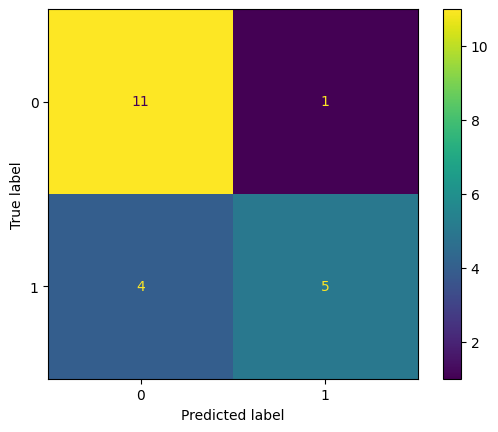

In [61]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

print(cm)

ConfusionMatrixDisplay(cm).plot()